# Spheroidal Density: BFE fit vs truth

Build a `MultipoleExpansion` from a triaxial NFW-like spheroid and compare
the reconstructed density, potential, and acceleration against the analytical input.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from bfeax import MultipoleExpansion, SpheroidDensity

## 1. Define the spheroid and build the expansion

In [3]:
# Triaxial NFW: alpha=1, beta=3, gamma=1
params = dict(
    rho0=1.0, alpha=1.0, beta=3.0, gamma=1.0, a=10.0,
    p=0.8, q=0.5,
)
grid = dict(r_min=1e-2, r_max=300.0, n_r=128, l_max=8)

# Analytical density (for ground truth)
rho_true = SpheroidDensity(**params, n_r=512, r_min=1e-3, r_max=1e4)

# Build the multipole expansion
exp = MultipoleExpansion.from_spheroid(**params, **grid)
print(f"l_max = {exp.l_max}, n_r = {grid['n_r']}")

l_max = 8, n_r = 128


## 2. Set up an x–z grid (y = 0 slice)

In [4]:
N = 200
lim = 40.0
x1d = jnp.linspace(-lim, lim, N)
z1d = jnp.linspace(-lim, lim, N)
X, Z = jnp.meshgrid(x1d, z1d, indexing="ij")
Y = jnp.zeros_like(X)

## 3. Density: truth vs BFE reconstruction

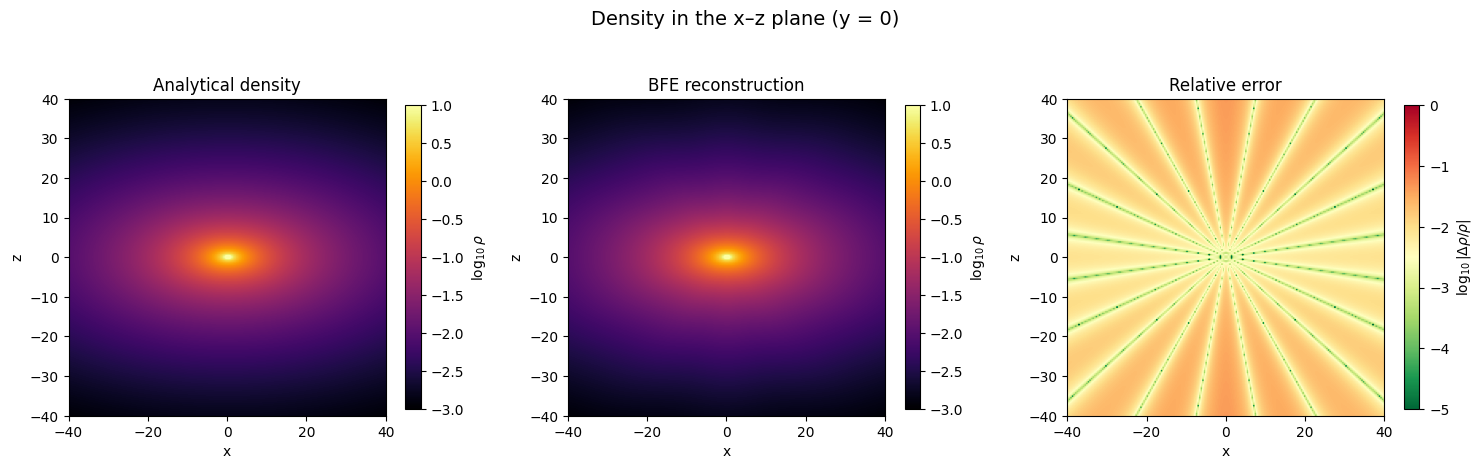

Median relative density error (0.1 < r < 200): 9.64e-03


In [5]:
rho_ana = jax.vmap(jax.vmap(rho_true))(X, Y, Z)
rho_rec = jax.vmap(jax.vmap(exp.density))(X, Y, Z)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

vmin, vmax = -3, 1
extent = [-lim, lim, -lim, lim]
kw = dict(extent=extent, origin="lower", cmap="inferno", vmin=vmin, vmax=vmax)

im0 = axes[0].imshow(jnp.log10(rho_ana).T, **kw)
axes[0].set_title("Analytical density")

im1 = axes[1].imshow(jnp.log10(jnp.clip(rho_rec, 1e-30)).T, **kw)
axes[1].set_title("BFE reconstruction")

# Relative error
rel_err = jnp.abs(rho_rec - rho_ana) / (jnp.abs(rho_ana) + 1e-30)
im2 = axes[2].imshow(
    jnp.log10(jnp.clip(rel_err, 1e-6, 1.0)).T,
    extent=extent, origin="lower", cmap="RdYlGn_r", vmin=-5, vmax=0,
)
axes[2].set_title("Relative error")

for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("z")
    ax.set_aspect("equal")

plt.colorbar(im0, ax=axes[0], label=r"$\log_{10}\rho$", shrink=0.8)
plt.colorbar(im1, ax=axes[1], label=r"$\log_{10}\rho$", shrink=0.8)
plt.colorbar(im2, ax=axes[2], label=r"$\log_{10}|\Delta\rho/\rho|$", shrink=0.8)

fig.suptitle("Density in the x–z plane (y = 0)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print summary stats (exclude the outermost ring where BFE extrapolates)
r_grid = jnp.sqrt(X**2 + Z**2)
mask = (r_grid > 0.1) & (r_grid < 200)
print(f"Median relative density error (0.1 < r < 200): {float(jnp.median(rel_err[mask])):.2e}")

## 4. Potential

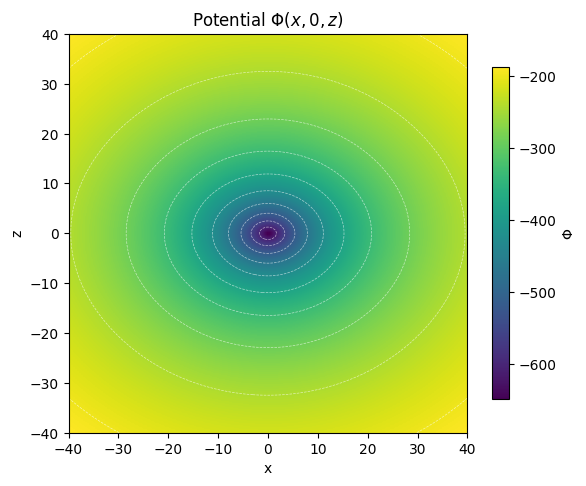

In [6]:
phi_vals = jax.vmap(jax.vmap(exp))(X, Y, Z)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    phi_vals.T,
    extent=extent, origin="lower", cmap="viridis",
)
# Contour lines
levels = np.linspace(float(phi_vals.min()), float(phi_vals.max()) * 0.1, 15)
ax.contour(
    np.array(phi_vals.T), levels=levels,
    extent=extent, colors="w", linewidths=0.5, alpha=0.6,
)
ax.set_xlabel("x")
ax.set_ylabel("z")
ax.set_aspect("equal")
ax.set_title(r"Potential $\Phi(x, 0, z)$")
plt.colorbar(im, ax=ax, label=r"$\Phi$", shrink=0.8)
plt.tight_layout()
plt.show()

## 5. Acceleration field

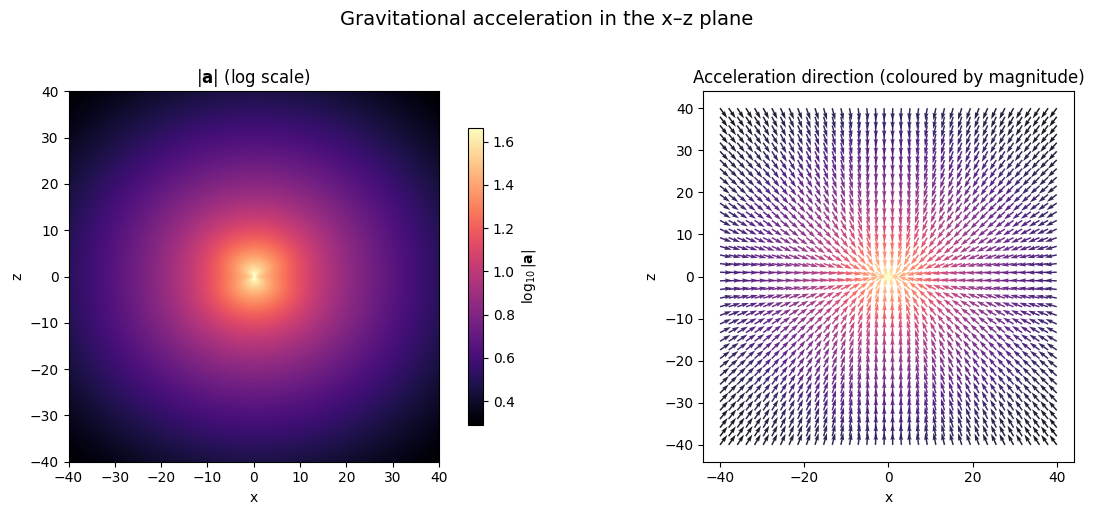

In [7]:
# Evaluate on a coarser grid for quiver readability
N_q = 40
x_q = jnp.linspace(-lim, lim, N_q)
z_q = jnp.linspace(-lim, lim, N_q)
Xq, Zq = jnp.meshgrid(x_q, z_q, indexing="ij")
Yq = jnp.zeros_like(Xq)

def acc_point(x, y, z):
    ax, ay, az = exp.acceleration(x, y, z)
    return ax, az

ax_vals, az_vals = jax.vmap(jax.vmap(acc_point))(Xq, Yq, Zq)
a_mag = jnp.sqrt(ax_vals**2 + az_vals**2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: acceleration magnitude (on fine grid, reusing potential for background)
ax_full_x, _, ax_full_z = jax.vmap(jax.vmap(exp.acceleration))(X, Y, Z)
a_mag_full = jnp.sqrt(ax_full_x**2 + ax_full_z**2)
im = axes[0].imshow(
    jnp.log10(a_mag_full).T,
    extent=extent, origin="lower", cmap="magma",
)
axes[0].set_title(r"$|\mathbf{a}|$ (log scale)")
plt.colorbar(im, ax=axes[0], label=r"$\log_{10}|\mathbf{a}|$", shrink=0.8)

# Right: quiver plot
axes[1].quiver(
    np.array(Xq), np.array(Zq),
    np.array(ax_vals / a_mag), np.array(az_vals / a_mag),
    np.array(jnp.log10(a_mag)),
    cmap="magma", scale=30, width=0.004, alpha=0.9,
)
axes[1].set_title("Acceleration direction (coloured by magnitude)")

for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("z")
    ax.set_aspect("equal")

fig.suptitle("Gravitational acceleration in the x–z plane", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Radial profiles along x and z axes

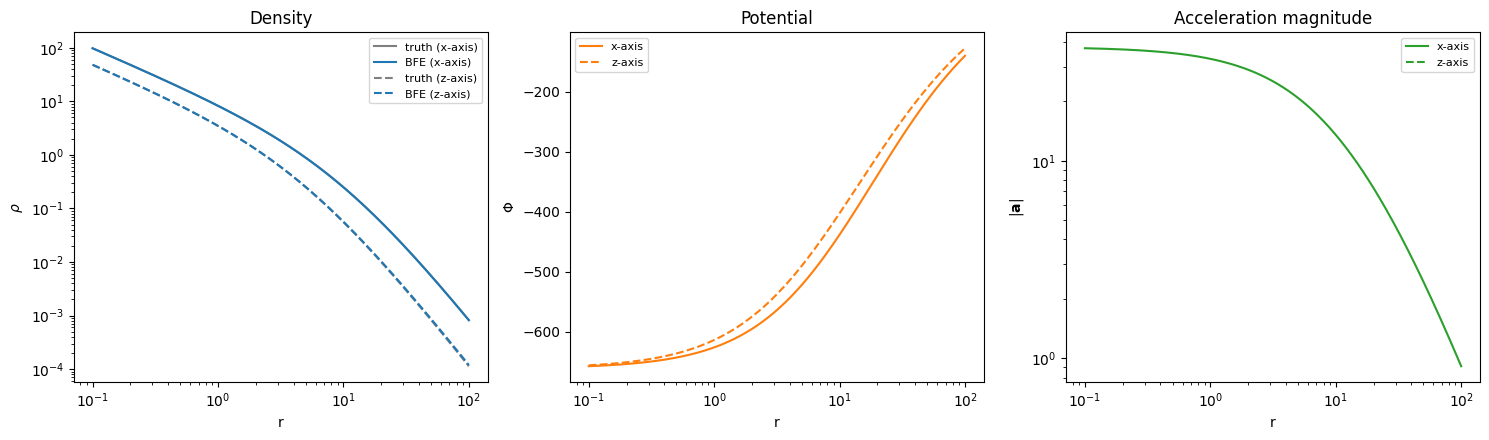

In [8]:
r_1d = jnp.logspace(-1, 2, 200)
zeros = jnp.zeros_like(r_1d)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for label, x_pts, z_pts, ls in [
    ("x-axis", r_1d, zeros, "-"),
    ("z-axis", zeros, r_1d, "--"),
]:
    y_pts = zeros

    # Density
    rho_t = jax.vmap(rho_true)(x_pts, y_pts, z_pts)
    rho_r = jax.vmap(exp.density)(x_pts, y_pts, z_pts)
    axes[0].loglog(r_1d, rho_t, ls, color="k", alpha=0.5, label=f"truth ({label})")
    axes[0].loglog(r_1d, rho_r, ls, color="C0", label=f"BFE ({label})")

    # Potential
    phi_r = jax.vmap(exp)(x_pts, y_pts, z_pts)
    axes[1].semilogx(r_1d, phi_r, ls, color="C1", label=label)

    # Acceleration magnitude
    ax_r, ay_r, az_r = jax.vmap(exp.acceleration)(x_pts, y_pts, z_pts)
    a_r = jnp.sqrt(ax_r**2 + ay_r**2 + az_r**2)
    axes[2].loglog(r_1d, a_r, ls, color="C2", label=label)

axes[0].set_ylabel(r"$\rho$")
axes[0].set_title("Density")
axes[0].legend(fontsize=8)

axes[1].set_ylabel(r"$\Phi$")
axes[1].set_title("Potential")
axes[1].legend(fontsize=8)

axes[2].set_ylabel(r"$|\mathbf{a}|$")
axes[2].set_title("Acceleration magnitude")
axes[2].legend(fontsize=8)

for ax in axes:
    ax.set_xlabel("r")

plt.tight_layout()
plt.show()